# `lci.lc.LightCurve` — All Effect Modes

`lcbinint.lc.LightCurve` computes magnification arrays for binary (and triple) lens events.  
Physics is configured via `lci.lc.Effects`; numerics via `lci.lc.Options`.  
Call `lc(times, **params)` to get a numpy array of magnifications.

Each section shows:
- The light curve
- Source trajectory + caustics in the lens plane

| Section | Key parameters |
|---------|---------------|
| 1. Point source (baseline) | t0, tE, u0, s, q, alpha |
| 2. Finite source + limb darkening | + rho, ld_c |
| 3. Annual parallax | + piEN, piEE, sky, t_ref |
| 4. Lens orbital motion — circular / Kepler | + g1, g2, g3 [, lom_szs, lom_ar] |
| 5. Xallarap — 4 modes | + xi_1, xi_2, … |
| 6. Binary source (independent) | + q_source, t0_2, u0_2 |
| 7. Binary source + xallarap (coupled) | + q_source, q_mass |

In [1]:
import sys
from pathlib import Path

# Prefer local build over any installed version
for build_dir in ("build", "build_new"):
    p = next(
        (r / build_dir for r in (Path.cwd(), *Path.cwd().parents) if (r / build_dir).is_dir()),
        None,
    )
    if p is not None:
        sys.path.insert(0, str(p))
        break

import numpy as np
import matplotlib.pyplot as plt
import lcbinint as lci

print("lcbinint:", lci.__file__)

lcbinint: /rogue1_8/nunota/lcbinint/build/lcbinint/__init__.py


In [2]:
def binary_caustics(s, q, n_points=600):
    """Compute binary lens caustics.

    Returns (bx, by): lists of numpy arrays, one per critical-curve branch.
    Lens 1 at origin, lens 2 at (s, 0) in the lens / image plane.
    """
    m1, m2 = 1.0 / (1 + q), q / (1 + q)
    bx = [[] for _ in range(4)]
    by = [[] for _ in range(4)]
    prev = None
    for phi in np.linspace(0, 2 * np.pi, n_points, endpoint=False):
        eiphi = np.exp(1j * phi)
        # Critical curve: m1/w^2 + m2/(w-s)^2 = e^{i*phi}
        # => eiphi*w^4 - 2s*eiphi*w^3 + (s^2*eiphi - 1)*w^2 + 2*m1*s*w - m1*s^2 = 0
        coeffs = [eiphi, -2*s*eiphi, s**2*eiphi - 1.0, 2*m1*s, -m1*s**2]
        roots = np.roots(coeffs)
        if prev is None:
            order = np.argsort(roots.real)
        else:
            order, used = [], set()
            for p_prev in prev:
                best = min(((abs(r - p_prev), j) for j, r in enumerate(roots) if j not in used))[1]
                order.append(best)
                used.add(best)
        roots = roots[order]
        prev = roots.copy()
        for i, w in enumerate(roots):
            # Lens equation: zeta = w - m1/conj(w) - m2/conj(w-s)
            z = w - m1 / np.conj(w) - m2 / np.conj(w - s)
            bx[i].append(z.real)
            by[i].append(z.imag)
    return [np.array(b) for b in bx], [np.array(b) for b in by]


def plot_geo(ax, traj, s, q, **plot_kw):
    """Plot source trajectory and caustics on ax."""
    bx, by = binary_caustics(s, q)
    for cx, cy in zip(bx, by):
        ax.plot(cx, cy, color="black", lw=0.9)
    ax.plot(traj["x"], traj["y"], **{"color": "steelblue", "lw": 1.5, **plot_kw})
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("source x [Einstein ring]")
    ax.set_ylabel("source y [Einstein ring]")

## 1. Point Source (Baseline)

Default `LightCurve()` uses `param_type='vbm'` and no higher-order effects.

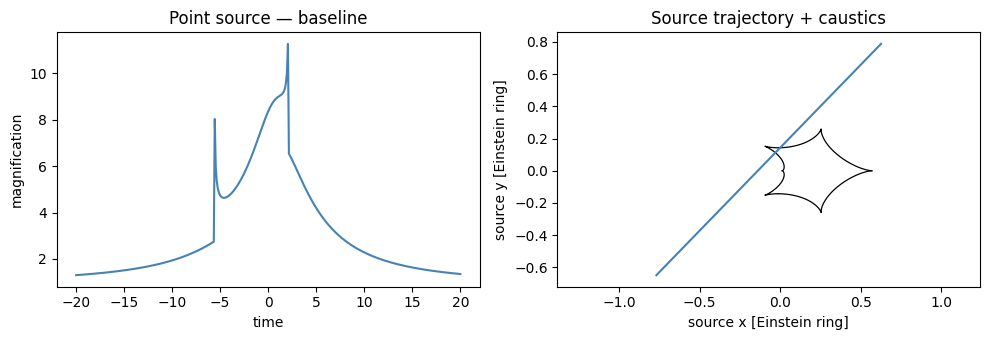

<lc.Effects>


In [3]:
t = np.linspace(-20, 20, 400)
p_base = dict(t0=0.0, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)

eff_basic = lci.lc.Effects()                     # all defaults: single source, no parallax
lc_basic  = lci.lc.LightCurve(effects=eff_basic)
mag_basic = lc_basic(t, **p_base)
traj_basic = lc_basic.source_trajectory(t, **p_base)

fig, (ax_lc, ax_geo) = plt.subplots(1, 2, figsize=(10, 3.5))
ax_lc.plot(t, mag_basic, lw=1.5, color="steelblue")
ax_lc.set(xlabel="time", ylabel="magnification", title="Point source — baseline")
plot_geo(ax_geo, traj_basic, p_base["s"], p_base["q"])
ax_geo.set_title("Source trajectory + caustics")
plt.tight_layout()
plt.show()
print(lc_basic.effects)

## 2. Finite Source + Limb Darkening

`rho` sets the angular source radius in Einstein ring units.  
`LimbDarkening.linear(u)` activates a linear profile: $I(\mu) = 1 - u(1-\mu)$.

We use a caustic-crossing event so the finite-source effect is visible; the top panel is zoomed in.

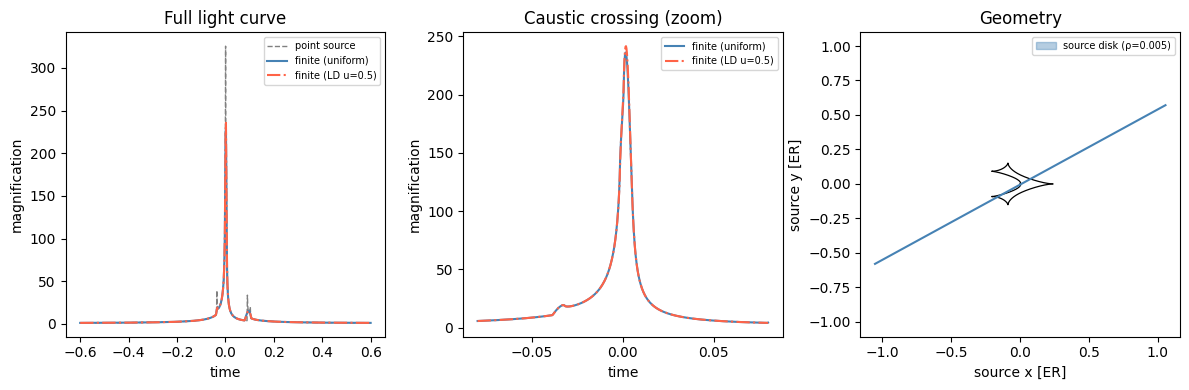

In [4]:
p_fs = dict(t0=0.0, tE=0.5, u0=-0.005, s=0.95, q=0.01, alpha=0.5, rho=5e-3)
t_fs_wide  = np.linspace(-0.6, 0.6, 800)
t_fs_zoom  = np.linspace(-0.08, 0.08, 600)   # zoom around caustic crossing

eff_ps  = lci.lc.Effects()
eff_ld  = lci.lc.Effects()
ld_prof = lci.lc.LimbDarkening.linear(0.5)

lc_ps_fs = lci.lc.LightCurve(effects=eff_ps)                          # uniform disk
lc_ld_fs = lci.lc.LightCurve(effects=eff_ld, limb_darkening=ld_prof)  # LD u=0.5
lc_pt    = lci.lc.LightCurve(effects=eff_ps)                          # point source

mag_pt      = lc_pt   (t_fs_wide, **{**p_fs, "rho": 0.0})
mag_ps_wide = lc_ps_fs(t_fs_wide, **p_fs)
mag_ld_wide = lc_ld_fs(t_fs_wide, **p_fs)
mag_ps_zoom = lc_ps_fs(t_fs_zoom, **p_fs)
mag_ld_zoom = lc_ld_fs(t_fs_zoom, **p_fs)

traj_fs = lc_pt.source_trajectory(t_fs_wide, **{**p_fs, "rho": 0.0})

fig = plt.figure(figsize=(12, 4))
ax_wide = fig.add_subplot(1, 3, 1)
ax_zoom = fig.add_subplot(1, 3, 2)
ax_geo  = fig.add_subplot(1, 3, 3)

for ax, t_arr, m_pt, m_ps, m_ld, title in [
    (ax_wide, t_fs_wide, mag_pt,      mag_ps_wide, mag_ld_wide, "Full light curve"),
    (ax_zoom, t_fs_zoom, None,         mag_ps_zoom, mag_ld_zoom, "Caustic crossing (zoom)"),
]:
    if m_pt is not None:
        ax.plot(t_arr, m_pt, ls="--", lw=1, color="gray",       label="point source")
    ax.plot(t_arr, m_ps, lw=1.5, color="steelblue",             label="finite (uniform)")
    ax.plot(t_arr, m_ld, lw=1.5, color="tomato",  ls="-.",     label="finite (LD u=0.5)")
    ax.set(xlabel="time", ylabel="magnification", title=title)
    ax.legend(fontsize=7)

bx, by = binary_caustics(p_fs["s"], p_fs["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
ax_geo.plot(traj_fs["x"], traj_fs["y"], color="steelblue", lw=1.5)
# Draw source disk at t=t0 (peak)
theta_disk = np.linspace(0, 2*np.pi, 100)
traj_t0 = lc_pt.source_trajectory(np.array([0.0]), **{**p_fs, "rho": 0.0})
ax_geo.fill(traj_t0["x"][0] + p_fs["rho"]*np.cos(theta_disk),
            traj_t0["y"][0] + p_fs["rho"]*np.sin(theta_disk),
            color="steelblue", alpha=0.4, label=f"source disk (ρ={p_fs['rho']})")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]", title="Geometry")
ax_geo.legend(fontsize=7)
plt.tight_layout()
plt.show()

## 3. Annual Parallax

`Effects(parallax=True, sky=..., t_ref=...)` activates the annual parallax correction.  
The sky coordinate and reference epoch are set inside `Effects`, not `Options`.  
Parameters `piEN`, `piEE` are the parallax vector in Einstein ring units.

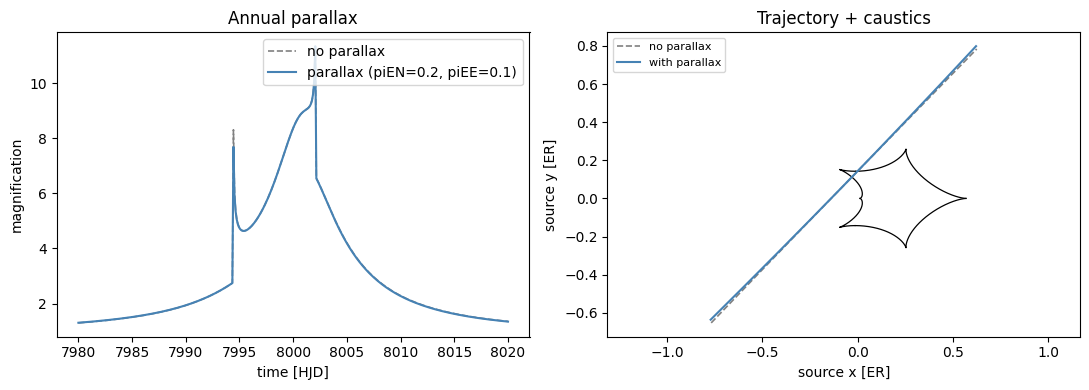

<lc.Effects parallax sky=set t_ref=8000.000000>


In [5]:
sky   = lci.obs.SkyCoord(ra=270.0, dec=-30.0)
t0_ref = 8000.0
t_par  = np.linspace(t0_ref - 20, t0_ref + 20, 400)

eff_nopar = lci.lc.Effects()
eff_par   = lci.lc.Effects(parallax=True, sky=sky, t_ref=t0_ref)

lc_nopar = lci.lc.LightCurve(effects=eff_nopar)
lc_par   = lci.lc.LightCurve(effects=eff_par)

p_par = dict(t0=t0_ref, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8, piEN=0.2, piEE=0.1)

mag_nopar   = lc_nopar(t_par, **p_par)
mag_par     = lc_par  (t_par, **p_par)
traj_nopar  = lc_nopar.source_trajectory(t_par, **p_par)
traj_par    = lc_par  .source_trajectory(t_par, **p_par)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax_lc = axes[0]
ax_lc.plot(t_par, mag_nopar, ls="--", lw=1.2, color="gray",      label="no parallax")
ax_lc.plot(t_par, mag_par,   lw=1.5,  color="steelblue",          label="parallax (piEN=0.2, piEE=0.1)")
ax_lc.set(xlabel="time [HJD]", ylabel="magnification", title="Annual parallax")
ax_lc.legend()

ax_geo = axes[1]
bx, by = binary_caustics(p_par["s"], p_par["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
ax_geo.plot(traj_nopar["x"], traj_nopar["y"], ls="--", lw=1.2, color="gray",    label="no parallax")
ax_geo.plot(traj_par  ["x"], traj_par  ["y"], lw=1.5,  color="steelblue",       label="with parallax")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]", title="Trajectory + caustics")
ax_geo.legend(fontsize=8)

plt.tight_layout()
plt.show()
print(lc_par.effects)

## 4. Lens Orbital Motion (LOM)

LOM modifies the lens geometry over time (not the source path).  
The trajectory plot uses the *static* (t=t0) caustic structure as reference.

| Parameter | Meaning |
|-----------|--------|
| g1 | $\dot{s}/s$ (fractional separation rate) |
| g2 | $\dot{\alpha}$ [rad/day] (angle rate) |
| g3 | $\dot{s}_z/s$ (line-of-sight rate) |
| lom_szs | $s_z/s$ at tref — Kepler only |
| lom_ar  | $a/s$ at tref — Kepler only |

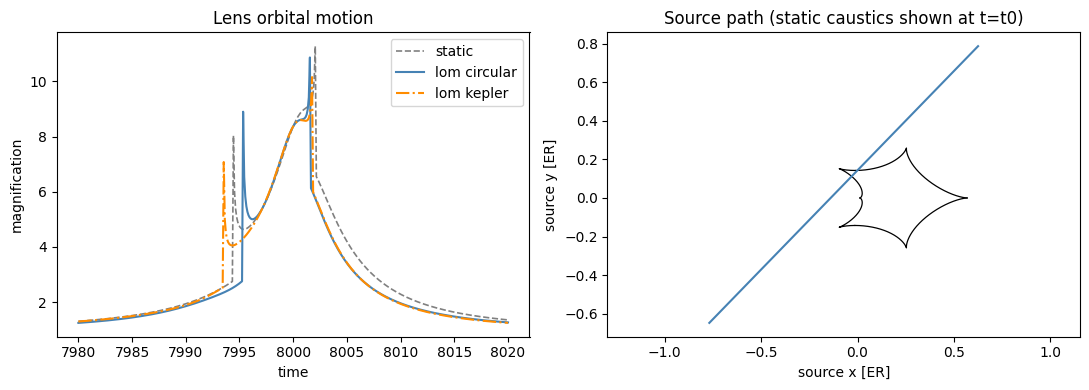

In [6]:
t_lom = np.linspace(t0_ref - 20, t0_ref + 20, 400)
p_lom = dict(t0=t0_ref, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)
lom_kw = dict(g1=0.01, g2=0.15, g3=0.0)

eff_static = lci.lc.Effects()
eff_circ   = lci.lc.Effects(orbital_motion="circular", t_ref=t0_ref)
eff_kepl   = lci.lc.Effects(orbital_motion="kepler",   t_ref=t0_ref)

lc_static = lci.lc.LightCurve(effects=eff_static)
lc_circ   = lci.lc.LightCurve(effects=eff_circ)
lc_kepl   = lci.lc.LightCurve(effects=eff_kepl)

mag_static = lc_static(t_lom, **p_lom)
mag_circ   = lc_circ  (t_lom, **p_lom, **lom_kw)
mag_kepl   = lc_kepl  (t_lom, **p_lom, **lom_kw, lom_szs=0.05, lom_ar=2.5)

# LOM modifies lens positions, not source path → trajectory is the same (static source frame)
traj_lom = lc_static.source_trajectory(t_lom, **p_lom)

fig, (ax_lc, ax_geo) = plt.subplots(1, 2, figsize=(11, 4))

ax_lc.plot(t_lom, mag_static, ls="--", lw=1.2, color="gray",       label="static")
ax_lc.plot(t_lom, mag_circ,   lw=1.5,  color="steelblue",           label="lom circular")
ax_lc.plot(t_lom, mag_kepl,   lw=1.5,  color="darkorange", ls="-.", label="lom kepler")
ax_lc.set(xlabel="time", ylabel="magnification", title="Lens orbital motion")
ax_lc.legend()

bx, by = binary_caustics(p_lom["s"], p_lom["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
ax_geo.plot(traj_lom["x"], traj_lom["y"], lw=1.5, color="steelblue")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]",
           title="Source path (static caustics shown at t=t0)")
plt.tight_layout()
plt.show()

## 5. Xallarap — All 4 Modes

Xallarap is source orbital motion — the source star orbits a companion.  
The trajectory is curved because the source position changes with the orbit.

| Mode | Parameterization | Key params |
|------|-----------------|------------|
| `orbital_elements` | Kepler orbit, elements | xi_1, xi_2, period_xa, ecc_xa, peri_xa, inc_xa |
| `circular_elements` | Circular orbit, elements | xi_1, xi_2, period_xa, inc_xa |
| `circular_velocity` | Circular orbit, pos+vel | xi_1, xi_2, w1, w2, w3 |
| `kepler_velocity` | Kepler orbit, pos+vel | xi_1, xi_2, w1, w2, w3, xa_szs, xa_ar |

**Elements modes**: `(t0, u0)` tracks CoM; `xi_1/xi_2` set orbit amplitude and sky direction.  
**Velocity modes**: `(t0, u0)` = CoM; `xi_1/xi_2` = source displacement at tref.

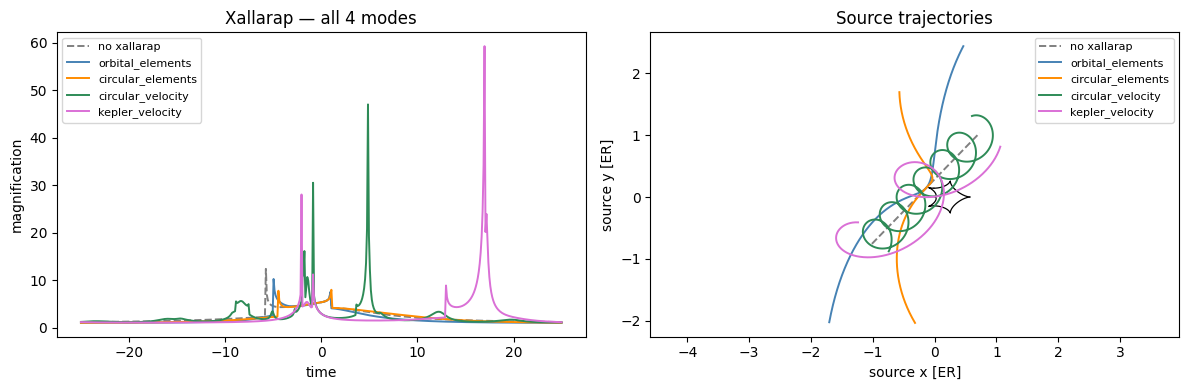

In [7]:
t_xa = np.linspace(-25, 25, 500)
p_xa_base = dict(t0=0.0, tE=20.0, u0=0.2, s=1.1, q=0.05, alpha=0.8)

mode_cfgs = [
    ("no xallarap",      lci.lc.Effects(),                                              {},
     "gray",      "--"),
    ("orbital_elements", lci.lc.Effects(xallarap="orbital_elements"),
     dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, ecc_xa=0.3, peri_xa=0.8, inc_xa=1.0),
     "steelblue",  "-"),
    ("circular_elements",lci.lc.Effects(xallarap="circular_elements"),
     dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0),
     "darkorange", "-"),
    ("circular_velocity",lci.lc.Effects(xallarap="circular_velocity"),
     dict(xi_1=0.3, xi_2=0.0, w1=0.01, w2=0.8, w3=0.1),
     "seagreen",   "-"),
    ("kepler_velocity",  lci.lc.Effects(xallarap="kepler_velocity"),
     dict(xi_1=0.3, xi_2=0.0, w1=0.01, w2=0.8, w3=0.1, xa_szs=0.1, xa_ar=2.0),
     "orchid",     "-"),
]

lcs = [lci.lc.LightCurve(effects=eff) for _, eff, _, _, _ in mode_cfgs]
mags  = [lc(t_xa, **p_xa_base, **kw) for lc, (_, _, kw, _, _) in zip(lcs, mode_cfgs)]
trajs = [lc.source_trajectory(t_xa, **p_xa_base, **kw)
         for lc, (_, _, kw, _, _) in zip(lcs, mode_cfgs)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ax_lc, ax_geo = axes

m0 = mags[0]
for (label, _, _, color, ls), mag in zip(mode_cfgs, mags):
    ax_lc.plot(t_xa, mag, label=label, lw=1.4, ls=ls, color=color)
ax_lc.set(xlabel="time", ylabel="magnification", title="Xallarap — all 4 modes")
ax_lc.legend(fontsize=8)

bx, by = binary_caustics(p_xa_base["s"], p_xa_base["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
for (label, _, _, color, ls), traj in zip(mode_cfgs, trajs):
    ax_geo.plot(traj["x"], traj["y"], label=label, lw=1.4, ls=ls, color=color)
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]", title="Source trajectories")
ax_geo.legend(fontsize=8)

plt.tight_layout()
plt.show()

### 5a. Identity check: `orbital_elements(ecc=0, peri=0)` ≡ `circular_elements`

In [8]:
lc_oe = lci.lc.LightCurve(effects=lci.lc.Effects(xallarap="orbital_elements"))
lc_ce = lci.lc.LightCurve(effects=lci.lc.Effects(xallarap="circular_elements"))
kw_id = dict(xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0)
m_oe  = lc_oe(t_xa, **p_xa_base, **kw_id, ecc_xa=0.0, peri_xa=0.0)
m_ce  = lc_ce(t_xa, **p_xa_base, **kw_id)
print("max |orbital_elements(ecc=0) − circular_elements|:", np.max(np.abs(m_oe - m_ce)))

max |orbital_elements(ecc=0) − circular_elements|: 0.0


## 6. Binary Source — Independent Trajectories

`Effects(source='binary')` computes the flux-weighted average of two sources:  
$$A_{\rm eff} = \frac{A_1 + q_{\rm source}\,A_2}{1 + q_{\rm source}}$$

Source 2 has its own `t0_2`, `u0_2` (and the same `tE`, `alpha`, `s`, `q`).

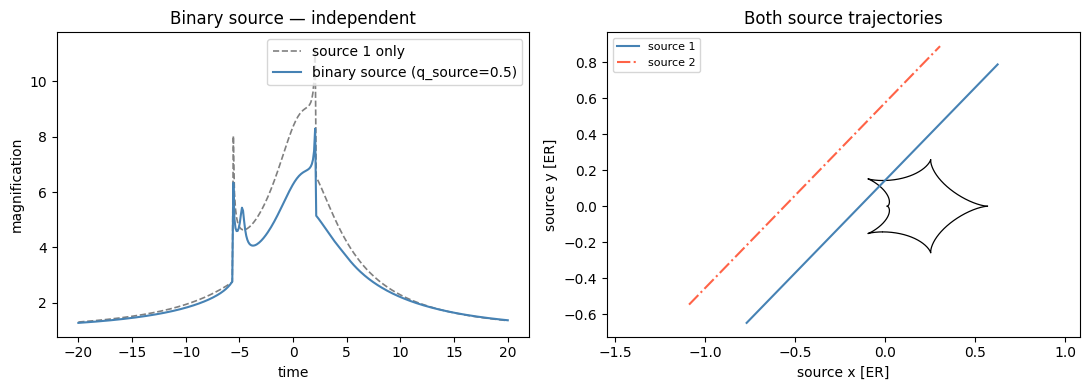

In [9]:
t_bs = np.linspace(-20, 20, 400)
p_bs = dict(t0=0.0, tE=20.0, u0=0.1, s=1.1, q=0.05, alpha=0.8)
t0_2, u0_2, q_source = 3.0, 0.4, 0.5

eff_s1 = lci.lc.Effects(source="single")
eff_bs = lci.lc.Effects(source="binary")

lc_s1 = lci.lc.LightCurve(effects=eff_s1)
lc_bs = lci.lc.LightCurve(effects=eff_bs)

mag_s1 = lc_s1(t_bs, **p_bs)
mag_bs = lc_bs(t_bs, **p_bs, q_source=q_source, t0_2=t0_2, u0_2=u0_2)

# Trajectories of both sources (use single-source lc to get each path)
traj_s1 = lc_s1.source_trajectory(t_bs, **p_bs)
p_bs2 = {**p_bs, "t0": t0_2, "u0": u0_2}
traj_s2 = lc_s1.source_trajectory(t_bs, **p_bs2)

fig, (ax_lc, ax_geo) = plt.subplots(1, 2, figsize=(11, 4))

ax_lc.plot(t_bs, mag_s1, ls="--", lw=1.2, color="gray",      label="source 1 only")
ax_lc.plot(t_bs, mag_bs, lw=1.5,  color="steelblue",          label=f"binary source (q_source={q_source})")
ax_lc.set(xlabel="time", ylabel="magnification", title="Binary source — independent")
ax_lc.legend()

bx, by = binary_caustics(p_bs["s"], p_bs["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
ax_geo.plot(traj_s1["x"], traj_s1["y"], lw=1.5, color="steelblue",  label="source 1")
ax_geo.plot(traj_s2["x"], traj_s2["y"], lw=1.5, color="tomato",    label="source 2", ls="-.")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]", title="Both source trajectories")
ax_geo.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 7. Binary Source + Xallarap (Coupled)

With `q_mass`, source 2's orbital amplitude is automatically coupled to source 1:  
$$\xi_{1,2} = -\xi_1 / q_{\rm mass}, \quad \xi_{2,2} = -\xi_2 / q_{\rm mass}$$

Both sources share the same orbit shape parameters (`period_xa`, `inc_xa`, …).

max |coupled − manual construction|: 0.0


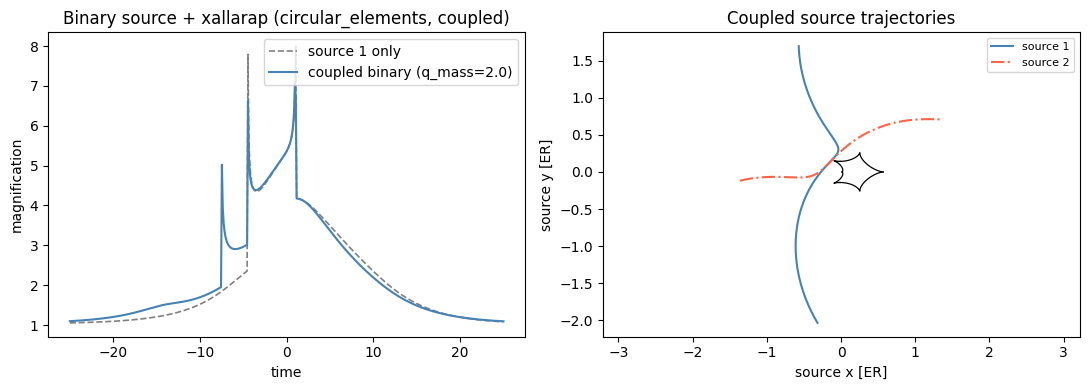

In [10]:
t_coupled = np.linspace(-25, 25, 500)
p_coupled = dict(t0=0.0, tE=20.0, u0=0.2, s=1.1, q=0.05, alpha=0.8,
                 xi_1=0.3, xi_2=0.0, period_xa=40.0, inc_xa=1.0)
q_mass   = 2.0
q_source = 1.0 / q_mass

eff_single  = lci.lc.Effects(xallarap="circular_elements", source="single")
eff_coupled = lci.lc.Effects(xallarap="circular_elements", source="binary")

lc_s1c = lci.lc.LightCurve(effects=eff_single)
lc_cpl = lci.lc.LightCurve(effects=eff_coupled)

mag_s1c     = lc_s1c(t_coupled, **p_coupled)
mag_coupled = lc_cpl (t_coupled, **p_coupled, q_source=q_source, q_mass=q_mass)

traj_s1c = lc_s1c.source_trajectory(t_coupled, **p_coupled)
# Source 2 trajectory: xi scaled by -1/q_mass
p_s2 = {**p_coupled, "xi_1": -p_coupled["xi_1"]/q_mass, "xi_2": -p_coupled["xi_2"]/q_mass}
traj_s2c = lc_s1c.source_trajectory(t_coupled, **p_s2)

print("max |coupled − manual construction|:",
      np.max(np.abs(mag_coupled -
             (lc_s1c(t_coupled, **p_coupled) + q_source * lc_s1c(t_coupled, **p_s2)) / (1 + q_source))))

fig, (ax_lc, ax_geo) = plt.subplots(1, 2, figsize=(11, 4))

ax_lc.plot(t_coupled, mag_s1c,     ls="--", lw=1.2, color="gray",     label="source 1 only")
ax_lc.plot(t_coupled, mag_coupled, lw=1.5,  color="steelblue",         label=f"coupled binary (q_mass={q_mass})")
ax_lc.set(xlabel="time", ylabel="magnification",
          title="Binary source + xallarap (circular_elements, coupled)")
ax_lc.legend()

bx, by = binary_caustics(p_coupled["s"], p_coupled["q"])
for cx, cy in zip(bx, by):
    ax_geo.plot(cx, cy, color="black", lw=0.9)
ax_geo.plot(traj_s1c["x"], traj_s1c["y"], lw=1.5, color="steelblue", label="source 1")
ax_geo.plot(traj_s2c["x"], traj_s2c["y"], lw=1.5, color="tomato",   label="source 2", ls="-.")
ax_geo.set_aspect("equal", adjustable="datalim")
ax_geo.set(xlabel="source x [ER]", ylabel="source y [ER]", title="Coupled source trajectories")
ax_geo.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Summary

```python
# Recommended: construct Effects explicitly, then pass to LightCurve
eff = lci.lc.Effects(
    source         = "single",          # "single" | "binary"
    orbital_motion = "static",          # "static" | "circular" | "kepler"  (+ t_ref)
    xallarap       = "none",            # "none" | "orbital_elements" | "circular_elements"
                                        #        | "circular_velocity" | "kepler_velocity"
    parallax       = False,             # True requires sky + t_ref
    sky            = lci.obs.SkyCoord(ra, dec),
    t_ref          = 8000.0,
)
opts = lci.lc.Options(source_bins=50, param_type="vbm")  # numerics
ld   = lci.lc.LimbDarkening.linear(0.5)                  # optional
lc   = lci.lc.LightCurve(effects=eff, options=opts, limb_darkening=ld)

mag  = lc(times, **params)                   # magnification array
traj = lc.source_trajectory(times, **params) # {"x": ..., "y": ...} in Einstein ring units
```